# # Notebook 2: Exploratory Data Analysis & Findings
#
# **Business questions answered here:**
 1. Which comorbidities drive longer hospital stays?
 2. Do readmitted patients stay significantly longer?
 3. Which facilities manage LOS most efficiently?
#
# **Each chart has a markdown cell above it explaining:**
 - What we were looking for
 - What the chart actually shows



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Global chart style — clean and professional
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})



In [ ]:
df = pd.read_csv(r'data/hospital_los_python_cleaned.csv')
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")

OVERALL_AVG_LOS = df['lengthofstay'].mean()
print(f"Overall average LOS: {OVERALL_AVG_LOS:.2f} days")



Loaded 100,000 rows, 32 columns
Overall average LOS: 4.00 days


---


## Chart 1: Average LOS per comorbidity condition

**Question:** Which single condition adds the most days to a hospital stay?

**Method:** For each of the 10 binary comorbidity flags, we calculate the
average LOS for patients WITH that condition, then subtract the overall average
to get the gap. Bars are sorted by gap descending.

**Finding (from SQL):** Dialysis/Renal Failure adds 2.14 days — the largest
single-condition driver. Every condition adds at least 1 day above baseline,
meaning no comorbidity in this dataset is operationally neutral.


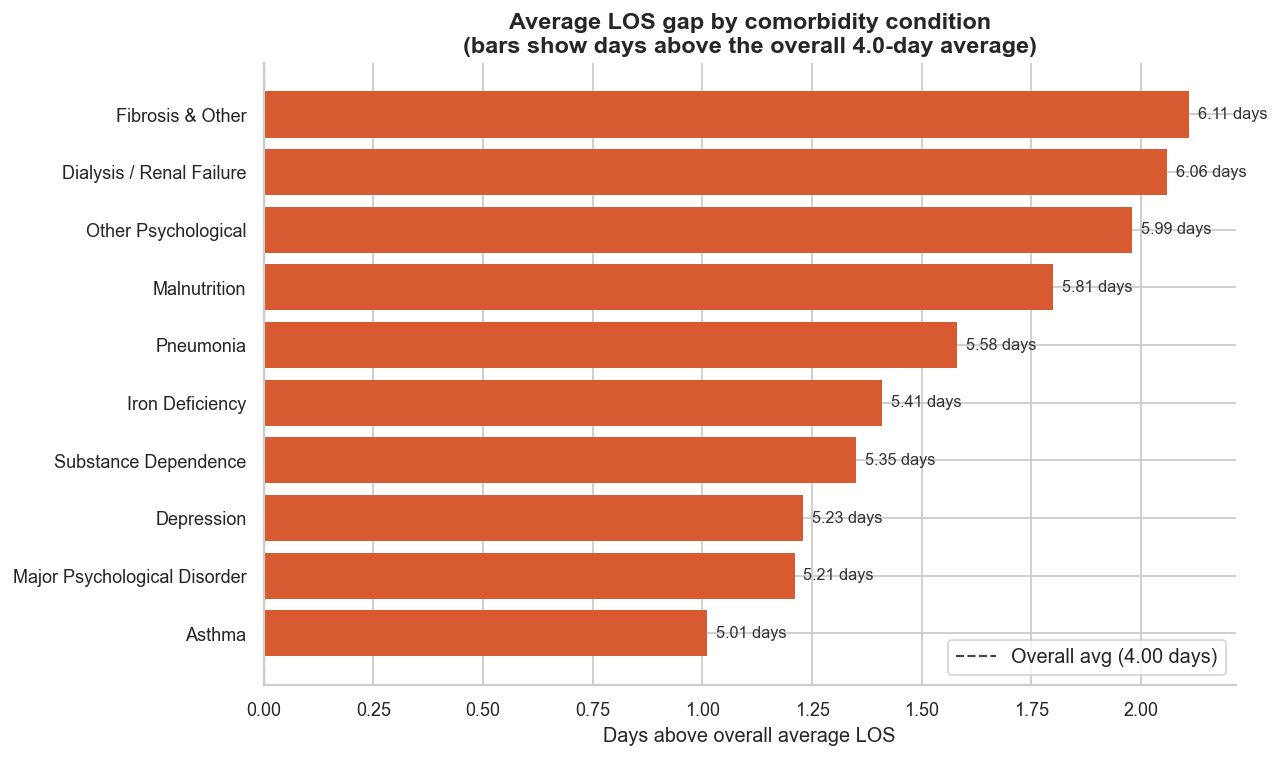

Saved: chart1_comorbidity_gap.png


In [16]:
comorbidity_cols = [
    'dialysisrenalendstage', 'asthma', 'irondef', 'pneum',
    'substancedependence', 'psychologicaldisordermajor', 'depress',
    'psychother', 'fibrosisandother', 'malnutrition'
]

# Human-readable labels for the chart
condition_labels = {
    'dialysisrenalendstage':       'Dialysis / Renal Failure',
    'asthma':                      'Asthma',
    'irondef':                     'Iron Deficiency',
    'pneum':                       'Pneumonia',
    'substancedependence':         'Substance Dependence',
    'psychologicaldisordermajor':  'Major Psychological Disorder',
    'depress':                     'Depression',
    'psychother':                  'Other Psychological',
    'fibrosisandother':            'Fibrosis & Other',
    'malnutrition':                'Malnutrition',
}

# Build summary: avg LOS when condition = 1, and gap from overall average
comorbidity_summary = []
for col in comorbidity_cols:
    avg_with = df[df[col] == 1]['lengthofstay'].mean()
    count    = df[col].sum()
    gap      = avg_with - OVERALL_AVG_LOS
    comorbidity_summary.append({
        'condition': condition_labels[col],
        'avg_los':   round(avg_with, 2),
        'gap':       round(gap, 2),
        'count':     int(count)
    })

comorb_df = pd.DataFrame(comorbidity_summary).sort_values('gap', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#D85A30' if g > 0 else '#378ADD' for g in comorb_df['gap']]
bars = ax.barh(comorb_df['condition'], comorb_df['gap'], color=colors, edgecolor='none')

# Reference line at 0 = overall average
ax.axvline(0, color='#444', linewidth=1.2, linestyle='--', label=f'Overall avg ({OVERALL_AVG_LOS:.2f} days)')

# Annotate each bar with avg LOS value
for bar, avg in zip(bars, comorb_df['avg_los']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{avg:.2f} days', va='center', ha='left', fontsize=9, color='#333')

ax.set_xlabel('Days above overall average LOS')
ax.set_title('Average LOS gap by comorbidity condition\n(bars show days above the overall 4.0-day average)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(r'notebooks\chart1_comorbidity_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart1_comorbidity_gap.png")



---


## Chart 2: Average LOS by comorbidity count (0 to 5 conditions)

**Question:** Does LOS increase predictably as patients carry more conditions?

**Finding:** Yes — LOS rises from 3.21 days at 0 conditions to approximately
9+ days at 5 conditions, adding roughly 1.5 days per additional condition.
Even 1 condition pushes patients 0.99 days above the overall average.
This means complexity effects begin at admission, not just in high-complexity cases.


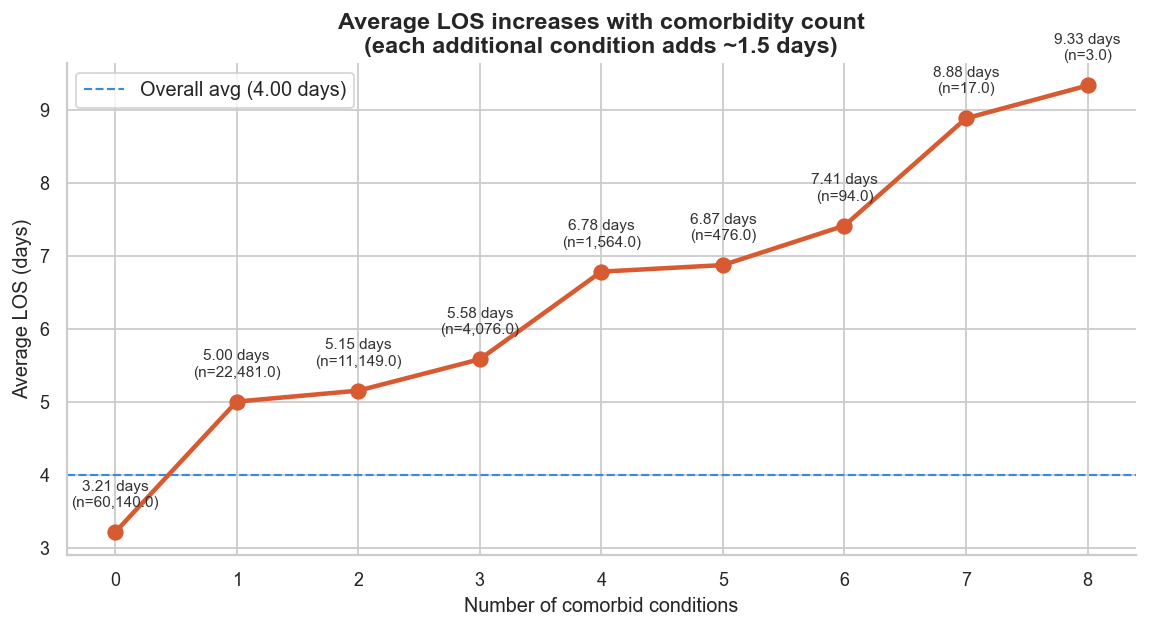

In [17]:
count_summary = df.groupby('comorbidity_count').agg(
    avg_los=('lengthofstay', 'mean'),
    patient_count=('lengthofstay', 'count')
).reset_index()
count_summary['avg_los'] = count_summary['avg_los'].round(2)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(count_summary['comorbidity_count'], count_summary['avg_los'],
        marker='o', color='#D85A30', linewidth=2.5, markersize=8, zorder=3)

# Annotate each point with avg LOS and patient count
for _, row in count_summary.iterrows():
    ax.annotate(
        f"{row['avg_los']:.2f} days\n(n={row['patient_count']:,})",
        xy=(row['comorbidity_count'], row['avg_los']),
        xytext=(0, 14), textcoords='offset points',
        ha='center', fontsize=8.5, color='#333'
    )

# Reference line for overall average
ax.axhline(OVERALL_AVG_LOS, color='#378ADD', linewidth=1.2,
           linestyle='--', label=f'Overall avg ({OVERALL_AVG_LOS:.2f} days)')

ax.set_xlabel('Number of comorbid conditions')
ax.set_ylabel('Average LOS (days)')
ax.set_title('Average LOS increases with comorbidity count\n(each additional condition adds ~1.5 days)')
ax.set_xticks(count_summary['comorbidity_count'])
ax.legend()
plt.tight_layout()
plt.savefig(r'notebooks\chart2_los_by_comorbidity_count.png', dpi=150, bbox_inches='tight')
plt.show()



---


## Chart 3: Average LOS by readmission count (0 through 5)

**Question:** Does each prior admission add measurable days to the current stay?

**Finding:** Yes — LOS rises linearly from 2.72 days (first visit) to 8.29 days
(5+ prior admissions). The sharpest jump is between rcount 1 and 2 (+1.57 days),
suggesting that crossing into multiple readmissions marks a meaningful clinical threshold.


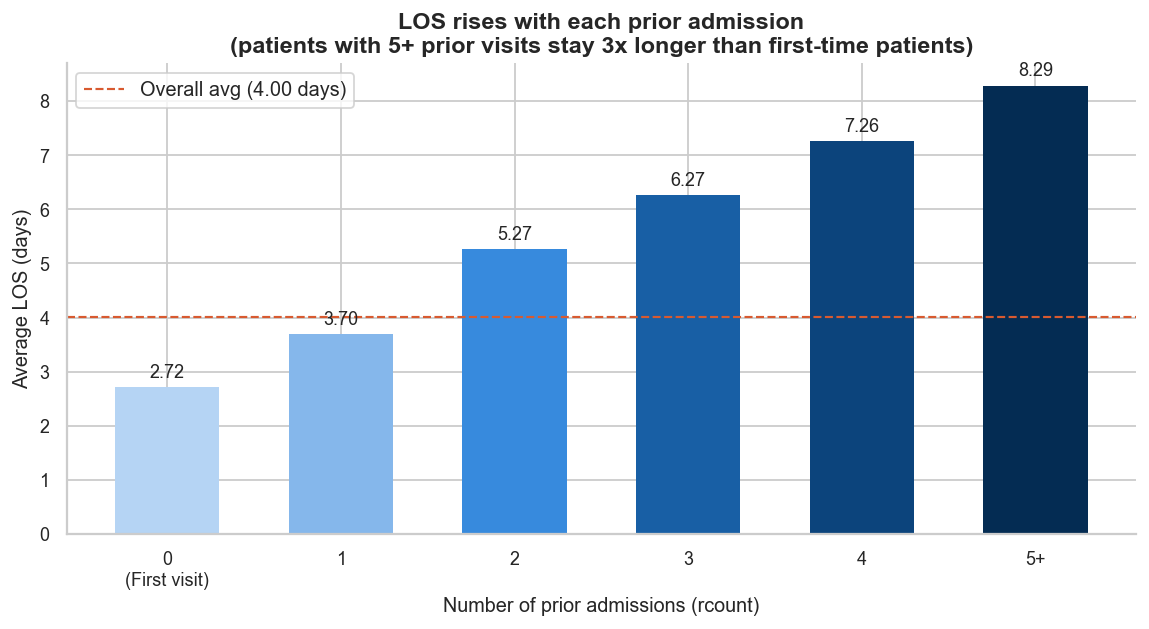

In [18]:
rcount_summary = df.groupby('rcount').agg(
    avg_los=('lengthofstay', 'mean'),
    patient_count=('lengthofstay', 'count')
).reset_index()
rcount_summary['avg_los'] = rcount_summary['avg_los'].round(2)

# Colour bars from light to dark as rcount increases
palette = ['#B5D4F4', '#85B7EB', '#378ADD', '#185FA5', '#0C447C', '#042C53']

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(rcount_summary['rcount'], rcount_summary['avg_los'],
              color=palette[:len(rcount_summary)], edgecolor='none', width=0.6)

# Annotate bars
for bar, row in zip(bars, rcount_summary.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{row.avg_los:.2f}', ha='center', va='bottom', fontsize=10, fontweight='500')

ax.axhline(OVERALL_AVG_LOS, color='#D85A30', linewidth=1.2,
           linestyle='--', label=f'Overall avg ({OVERALL_AVG_LOS:.2f} days)')

ax.set_xlabel('Number of prior admissions (rcount)')
ax.set_ylabel('Average LOS (days)')
ax.set_title('LOS rises with each prior admission\n(patients with 5+ prior visits stay 3x longer than first-time patients)')
ax.set_xticks(rcount_summary['rcount'])
ax.set_xticklabels(['0\n(First visit)', '1', '2', '3', '4', '5+'])
ax.legend()
plt.tight_layout()
plt.savefig(r'notebooks\chart3_los_by_rcount.png', dpi=150, bbox_inches='tight')
plt.show()



---


## Chart 4: LOS distribution by facility (box plot)

**Question:** Is Facility E's higher average LOS driven by genuine operational
differences, or just a few extreme outliers pulling the average up?

**Finding:** Facility E has a higher median AND more high-end outliers,
particularly the 15+ day extended stays. Other facilities cluster tightly.
After complexity adjustment (SQL Q3b), much of the gap is explained by
patient mix, but Facility E's extended stays remain disproportionate.


C:\Users\HP\AppData\Local\Temp\ipykernel_19388\1752402092.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


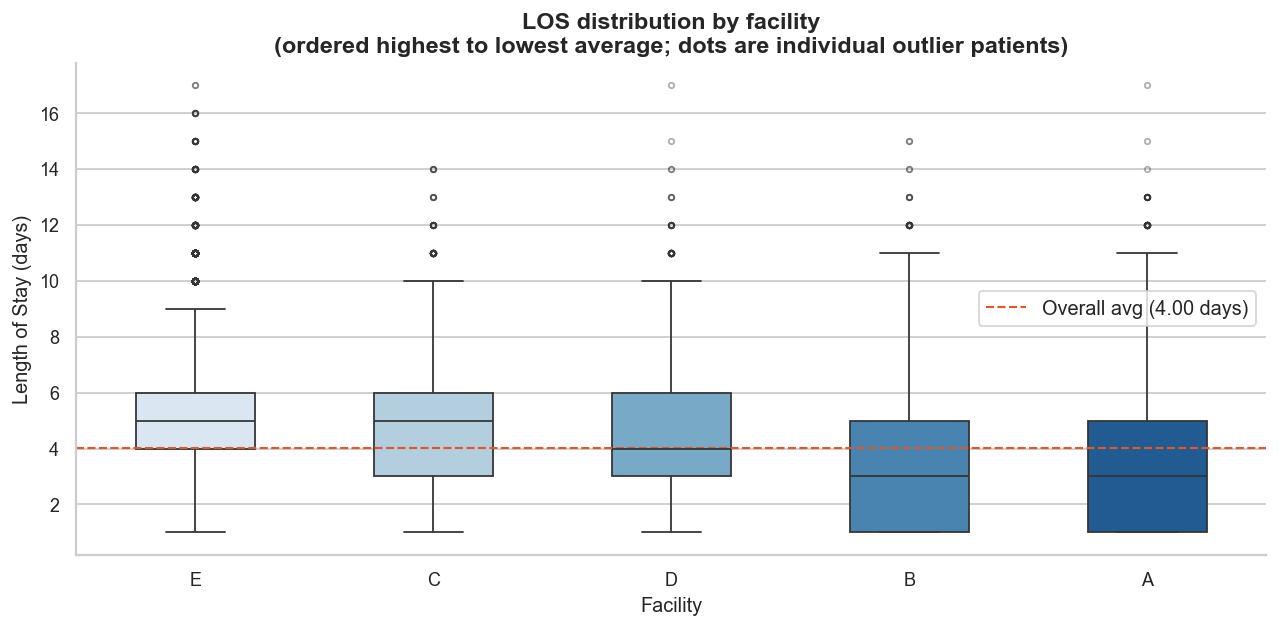

In [12]:
facility_order = (df.groupby('facid')['lengthofstay']
                    .mean()
                    .sort_values(ascending=False)
                    .index.tolist())

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=df, x='facid', y='lengthofstay',
    order=facility_order,
    palette='Blues',
    width=0.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.4, color='#888'),
    ax=ax
)

ax.axhline(OVERALL_AVG_LOS, color='#D85A30', linewidth=1.2,
           linestyle='--', label=f'Overall avg ({OVERALL_AVG_LOS:.2f} days)')

ax.set_xlabel('Facility')
ax.set_ylabel('Length of Stay (days)')
ax.set_title('LOS distribution by facility\n(ordered highest to lowest average; dots are individual outlier patients)')
ax.legend()
plt.tight_layout()
plt.savefig(r'notebooks\chart4_los_by_facility_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()



---


## Chart 5: Lab value correlation heatmap

**Question:** Which lab values correlate most strongly with LOS?

**Finding:** BUN (bloodureanitro) shows the strongest positive correlation
with LOS, consistent with the SQL finding that extended-stay patients averaged
37.46 mg/dL vs 12.48 for short-stay patients — a 3x difference.
Hematocrit shows a moderate negative correlation (lower red blood cell
percentage = longer stay), consistent with anaemia in sicker patients.


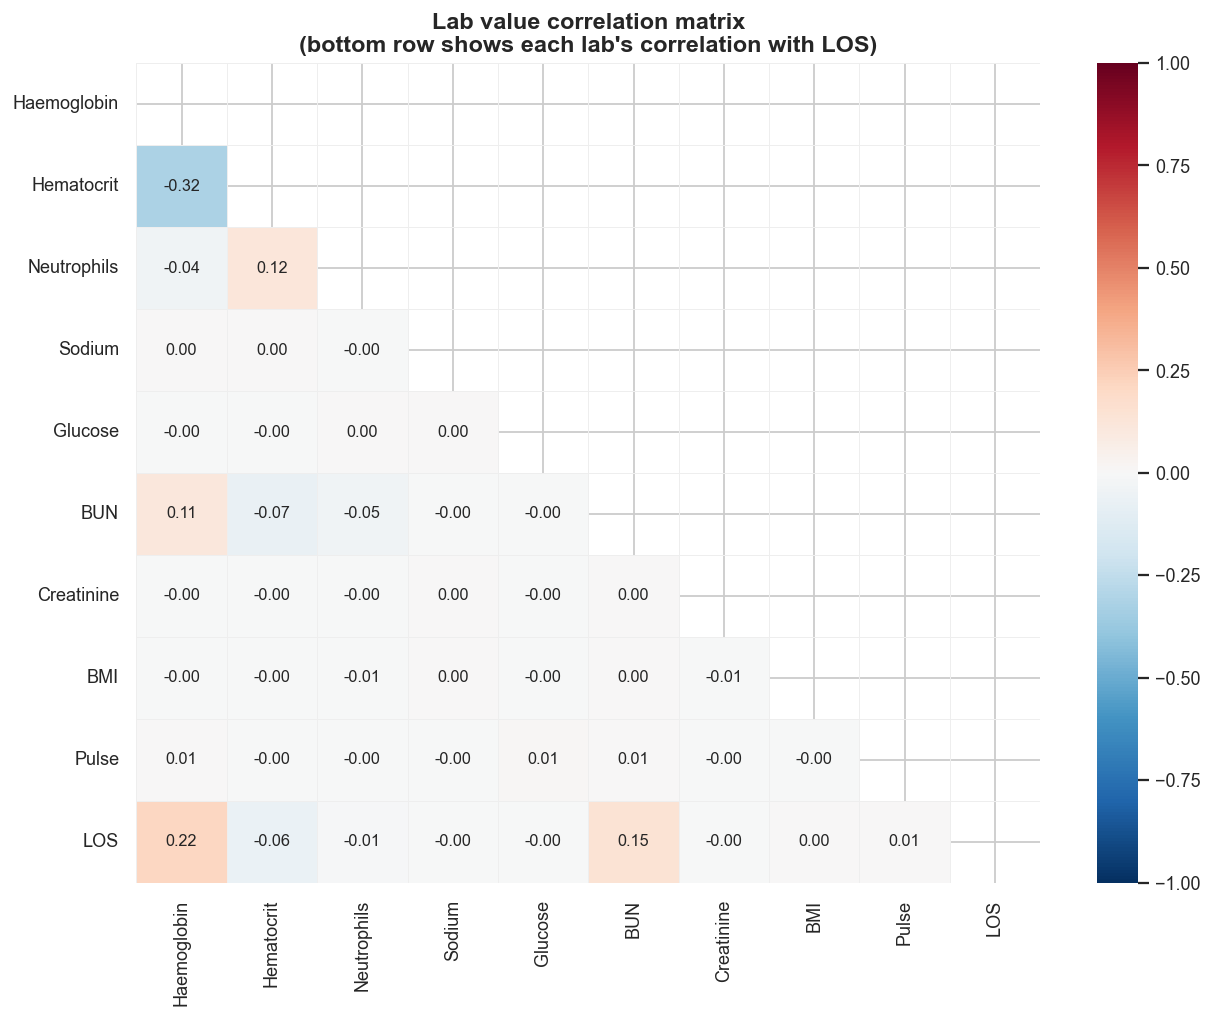


Correlations with LOS (sorted):
Haemoglobin    0.218
BUN            0.148
Pulse          0.007
BMI            0.000
Glucose       -0.003
Sodium        -0.004
Creatinine    -0.004
Neutrophils   -0.011
Hematocrit    -0.064
Name: LOS, dtype: float64


In [13]:
lab_cols = ['hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose',
            'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'lengthofstay']

# Human-readable axis labels
lab_labels = {
    'hemo': 'Haemoglobin',
    'hematocrit': 'Hematocrit',
    'neutrophils': 'Neutrophils',
    'sodium': 'Sodium',
    'glucose': 'Glucose',
    'bloodureanitro': 'BUN',
    'creatinine': 'Creatinine',
    'bmi': 'BMI',
    'pulse': 'Pulse',
    'lengthofstay': 'LOS'
}

corr_df = df[lab_cols].rename(columns=lab_labels).corr()

fig, ax = plt.subplots(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_df, dtype=bool))  # hide upper triangle (redundant)
sns.heatmap(
    corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='#eee',
    annot_kws={'size': 9},
    ax=ax
)

ax.set_title('Lab value correlation matrix\n(bottom row shows each lab\'s correlation with LOS)')
plt.tight_layout()
plt.savefig(r'notebooks\chart5_lab_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the LOS row specifically for easy reading
print("\nCorrelations with LOS (sorted):")
print(corr_df['LOS'].drop('LOS').sort_values(ascending=False).round(3))



---


## Chart 6: LOS category breakdown by facility (stacked bar)

**Question:** Does one facility systematically produce more extended stays,
or does the LOS distribution look similar across all facilities?

**Finding:** Facility E has a visibly higher proportion of Extended (15+ day)
stays versus all other facilities. Facility C has zero extended stays.
This is the clearest facility-level operational signal in the dataset.


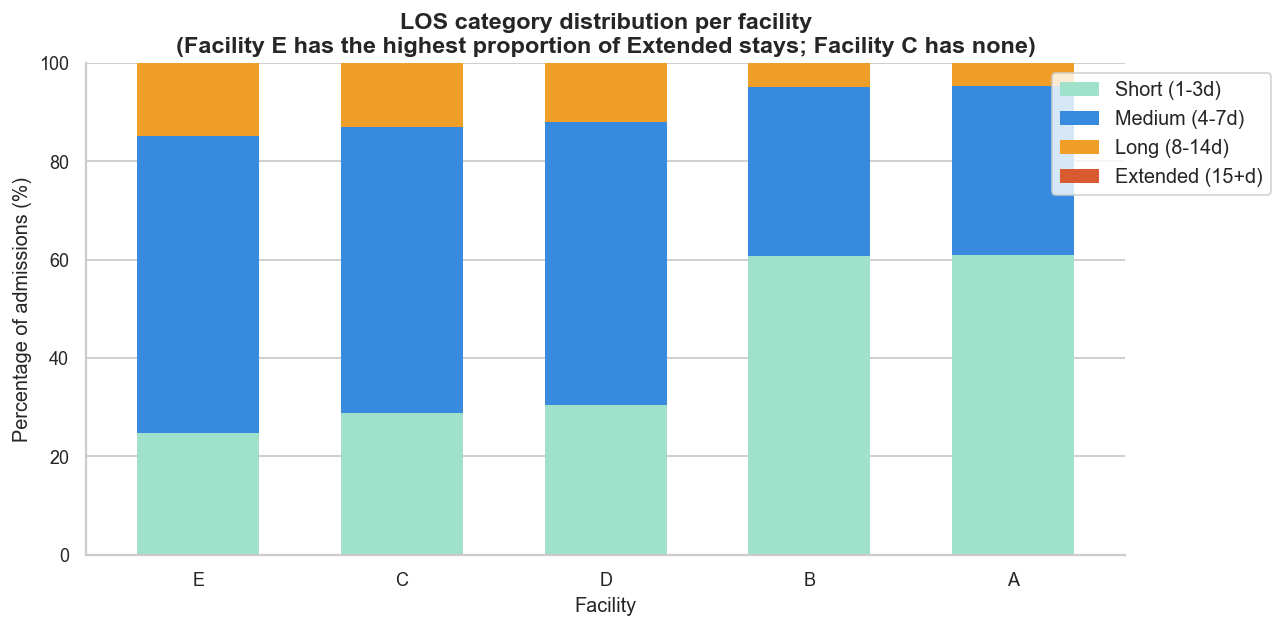

In [14]:
los_cats = ['1 - Short (1-3 days)', '2 - Medium (4-7 days)',
            '3 - Long (8-14 days)', '4 - Extended (15+ days)']
cat_labels = ['Short (1-3d)', 'Medium (4-7d)', 'Long (8-14d)', 'Extended (15+d)']
cat_colors = ['#9FE1CB', '#378ADD', '#EF9F27', '#D85A30']

stacked = (pd.crosstab(df['facid'], df['los_category'], normalize='index')
             .reindex(columns=los_cats) * 100)
stacked.columns = cat_labels
stacked = stacked.loc[facility_order]  # same order as Chart 4

fig, ax = plt.subplots(figsize=(10, 5))

stacked.plot(kind='bar', stacked=True, ax=ax, color=cat_colors,
             edgecolor='none', width=0.6)

ax.set_xlabel('Facility')
ax.set_ylabel('Percentage of admissions (%)')
ax.set_title('LOS category distribution per facility\n(Facility E has the highest proportion of Extended stays; Facility C has none)')
ax.set_xticklabels(stacked.index, rotation=0)
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.savefig(r'notebooks\chart6_los_category_by_facility.png', dpi=150, bbox_inches='tight')
plt.show()



---


## Chart 7: BUN levels across LOS categories

**Question:** Does the BUN lab value visually track with LOS severity?

**Finding:** BUN rises clearly from short to extended stays — from 12.48
to 37.46 mg/dL. Values above 20 mg/dL are clinically elevated (normal is
7–20). Extended-stay patients are nearly double the upper normal limit on
average. This makes BUN a practical early-warning indicator for clinicians.


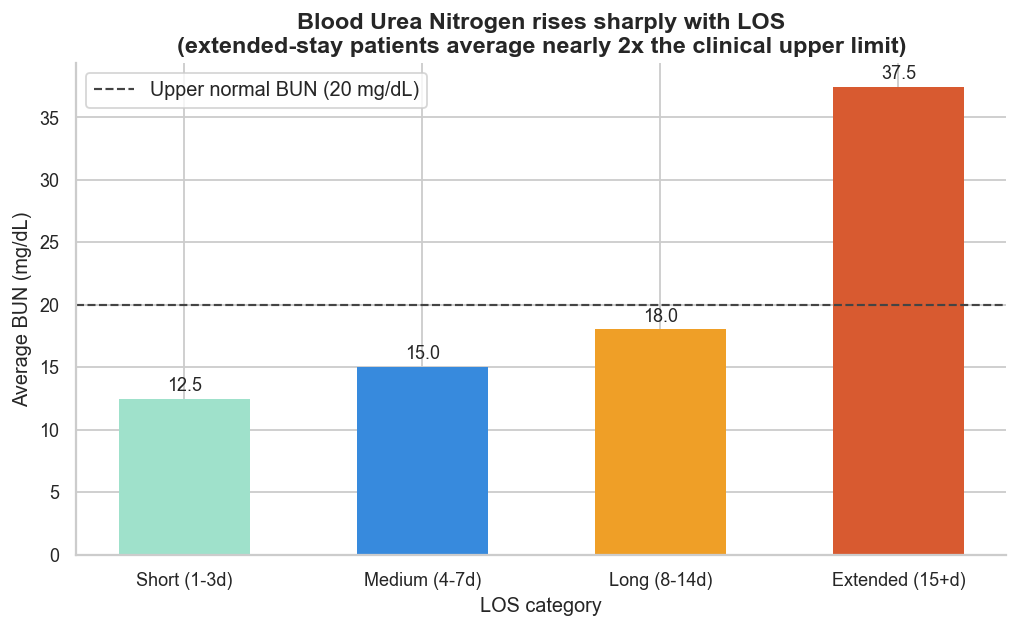

In [15]:
bun_summary = df.groupby('los_category')['bloodureanitro'].mean().reset_index()
bun_summary.columns = ['los_category', 'avg_bun']
bun_summary = bun_summary.sort_values('los_category')
bun_summary['label'] = cat_labels  # reuse labels from Chart 6

normal_bun_upper = 20  # clinical upper bound for normal BUN

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(bun_summary['label'], bun_summary['avg_bun'],
              color=cat_colors, edgecolor='none', width=0.55)

for bar, val in zip(bars, bun_summary['avg_bun']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10)

ax.axhline(normal_bun_upper, color='#444', linewidth=1.2, linestyle='--',
           label='Upper normal BUN (20 mg/dL)')

ax.set_ylabel('Average BUN (mg/dL)')
ax.set_xlabel('LOS category')
ax.set_title('Blood Urea Nitrogen rises sharply with LOS\n(extended-stay patients average nearly 2x the clinical upper limit)')
ax.legend()
plt.tight_layout()
plt.savefig(r'notebooks\chart7_bun_by_los_category.png', dpi=150, bbox_inches='tight')
plt.show()



---


## Summary of key visual findings

| Finding | Number |


| Largest single condition LOS driver | Dialysis/Renal Failure (+2.14 days) |

| LOS at 0 comorbidities | 3.21 days |

| LOS at 5 comorbidities | ~8.29 days |

| First visit avg LOS | 2.27 days |

| Readmitted avg LOS | 5.57 days |

| Readmission gap | +3.30 days |

| Highest avg LOS facility | E (5.16 days) |

| Lowest avg LOS facility | 3.27 days |

| BUN short-stay avg | 12.48 mg/dL |

| BUN extended-stay avg | 37.46 mg/dL |
